### A daily **sales series** from the three components every real series hides (TREND, SEASONALITY, NOISE).

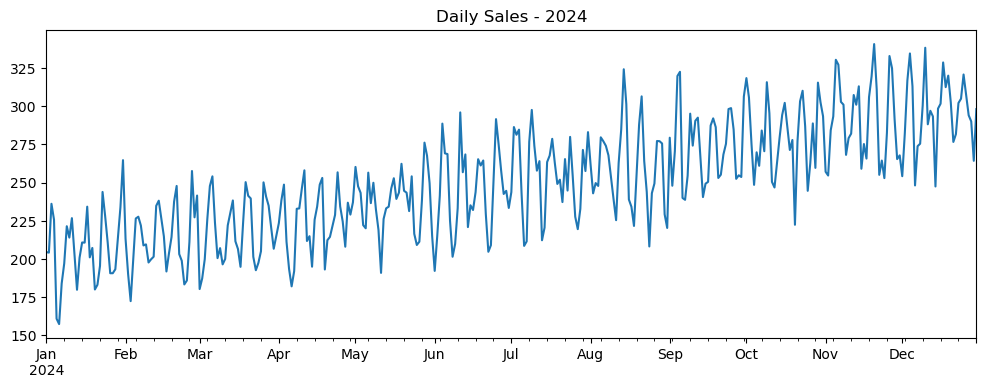

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

dates = pd.date_range("2024-01-01", periods=365, freq="D")

trend = np.linspace(200,300,365) #growth: 200 - 300 over the year
seasonality = 25 * np.sin(2 * np.pi * np.arange(365) / 7) # Weekly cycle, +-25
noise = rng.normal(0, 15, 365) # Honest randomness, σ=15

sales = trend + seasonality + noise

ts = pd.Series(sales, index=dates, name="daily_sales") # Index being dates unlocks resampling, rolling windows and calendar-aware slicing.
ts.plot(figsize=(12,4), title="Daily Sales - 2024")
plt.show()

2024-01-01    204.570756
2024-01-02    204.220751
2024-01-03    236.179416
2024-01-04    225.779740
2024-01-05    160.986280
2024-01-06    157.467736
2024-01-07    184.020171
2024-01-08    197.179438
2024-01-09    221.491572
2024-01-10    214.050066
Freq: D, Name: daily_sales, dtype: float64


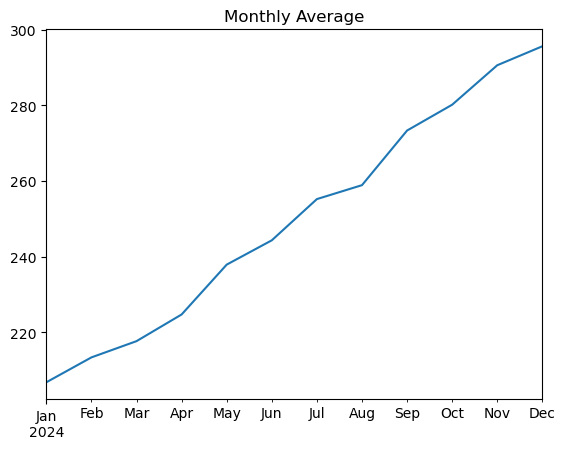

In [5]:
print(ts.head(10))
ts.resample("ME").mean().plot(title="Monthly Average")
plt.show()

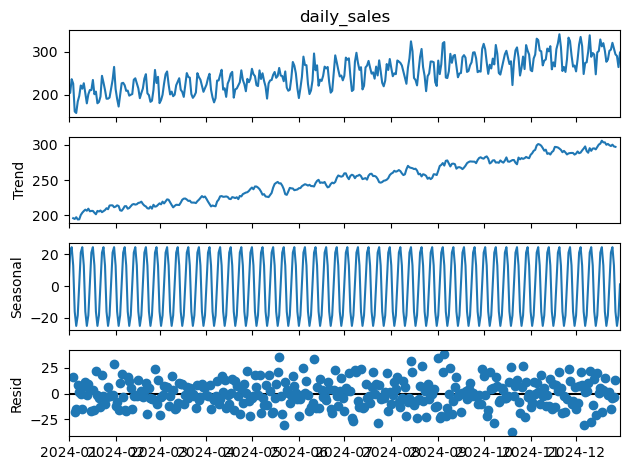

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(ts, model="additive", period=7)
decomp.plot()
plt.tight_layout()
plt.show()